In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats import multivariate_normal
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


In [49]:
df_train = pd.read_csv("Data_for_Lab06/Activity_Train.csv")
df_test = pd.read_csv("Data_for_Lab06/Activity_Test.csv")
df_val = pd.read_csv("Data_for_Lab06/Activity_Validation.csv")

In [50]:
X_train = df_train.drop('Activity', axis=1)
y_train = df_train['Activity']

In [51]:
X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

In [52]:
X_val = df_val.drop('Activity', axis=1)
y_val = df_val['Activity']

In [53]:
X_test.shape

(2060, 561)

In [54]:
X_train.shape

(6179, 561)

In [55]:
classes = np.unique(y_train)

class_means, class_covs, class_priors = {}, {}, {}

for cls in classes:
    X_cls = X_train[y_train == cls]
    class_means[cls] = np.mean(X_cls, axis=0)
    class_covs[cls] = np.cov(X_cls, rowvar=False)
    class_priors[cls] = X_cls.shape[0] / X_train.shape[0]

print("Finished Parameter Estimation\n")

numerators = []
for cls in classes:
    likelihood = multivariate_normal.pdf(
        np.array(X_test),
        mean=class_means[cls],
        cov=class_covs[cls],
        allow_singular=True
    )
    
    numerator = likelihood * class_priors[cls]
    numerators.append(numerator)

numerators = np.array(numerators)

total_probabilities = np.sum(numerators, axis=0).reshape(1, -1)

posteriors = numerators/total_probabilities

predictions_test = classes[np.argmax(posteriors, axis=0)]

print(f" Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")


numerators = np.swapaxes(numerators, 0, 1)
total_probabilities = np.sum(numerators, axis=1).reshape(-1, 1)
posteriors = numerators/total_probabilities
predictions_test = classes[np.argmax(posteriors, axis=1)]
print(f"\n Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")
print("\nFinished Test Prediction\n")

Finished Parameter Estimation



/home/user/.local/lib/python3.8/site-packages/scipy/stats/_multivariate.py:583: RuntimeWarning: overflow encountered in exp
  out = np.exp(self._logpdf(x, mean, cov_object))


 Numerator Shape: (6, 2060) 
 Total Probability Shape: (1, 2060) 
 Posterior Probability Shape: (6, 2060) 
 Prediction Shape: (2060,)

 Numerator Shape: (2060, 6) 
 Total Probability Shape: (2060, 1) 
 Posterior Probability Shape: (2060, 6) 
 Prediction Shape: (2060,)

Finished Test Prediction



/tmp/ipykernel_176776/536151776.py:29: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities
/tmp/ipykernel_176776/536151776.py:38: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[389   0   0   0   0   0]
 [356   0   0   0   0   0]
 [381   0   0   0   0   0]
 [344   0   0   0   0   0]
 [281   0   0   0   0   0]
 [308   0   0   0   0   1]]
Accuracy: 0.18932038834951456
Precision (Micro): 0.18932038834951456
Recall (Micro): 0.18932038834951456
F1-score (Micro): 0.18932038834951456
Precision (Macro): 0.19815444390480816
Recall (Macro): 0.16720604099244876
F1-score (Macro): 0.05404367840326094


/home/user/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


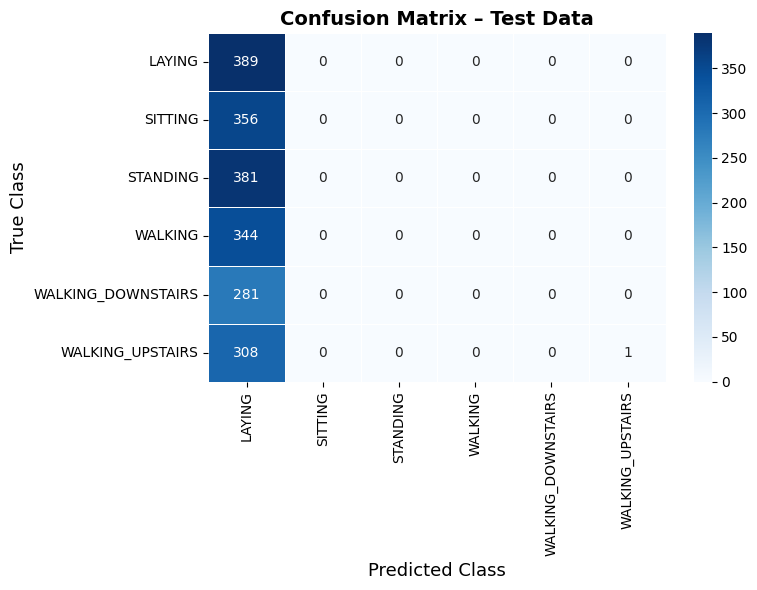

In [56]:
# Write the code for performance metrics evaluation
def evaluate_performance(y_true, y_pred, dataset_name):
    print(f"\nPerformance on {dataset_name} Data")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision (Micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (Micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (Micro):", f1_score(y_true, y_pred, average="micro"))

    print("Precision (Macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (Macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (Macro):", f1_score(y_true, y_pred, average="macro"))


def plot_confusion_matrix(y_true, y_pred, label, cmap='Blues'):
    """
    Plot a labelled confusion-matrix heatmap.
    """
    labels = sorted(np.unique(y_true))
    cm     = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=0.5)
    plt.xlabel('Predicted Class', fontsize=13)
    plt.ylabel('True Class',      fontsize=13)
    plt.title(f'Confusion Matrix – {label} Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [59]:
classes = np.unique(y_train)

class_means, class_covs, class_priors = {}, {}, {}

for cls in classes:
    X_cls = X_train[y_train == cls]
    class_means[cls] = np.mean(X_cls, axis=0)
    class_covs[cls] = np.cov(X_cls, rowvar=False)
    class_priors[cls] = X_cls.shape[0] / X_train.shape[0]

print("Finished Parameter Estimation\n")

numerators = []
for cls in classes:
    likelihood = multivariate_normal.pdf(
        np.array(X_val),
        mean=class_means[cls],
        cov=class_covs[cls],
        allow_singular=True
    )
    
    numerator = likelihood * class_priors[cls]
    numerators.append(numerator)

numerators = np.array(numerators)

total_probabilities = np.sum(numerators, axis=0).reshape(1, -1)

posteriors = numerators/total_probabilities

predictions_val = classes[np.argmax(posteriors, axis=0)]

print(f" Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")


numerators = np.swapaxes(numerators, 0, 1)
total_probabilities = np.sum(numerators, axis=1).reshape(-1, 1)
posteriors = numerators/total_probabilities
predictions_val = classes[np.argmax(posteriors, axis=1)]
print(f"\n Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")
print("\nFinished val Prediction\n")

Finished Parameter Estimation



/home/user/.local/lib/python3.8/site-packages/scipy/stats/_multivariate.py:583: RuntimeWarning: overflow encountered in exp
  out = np.exp(self._logpdf(x, mean, cov_object))


 Numerator Shape: (6, 2060) 
 Total Probability Shape: (1, 2060) 
 Posterior Probability Shape: (6, 2060) 
 Prediction Shape: (2060,)

 Numerator Shape: (2060, 6) 
 Total Probability Shape: (2060, 1) 
 Posterior Probability Shape: (2060, 6) 
 Prediction Shape: (2060,)

Finished val Prediction



/tmp/ipykernel_176776/3270419872.py:29: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities
/tmp/ipykernel_176776/3270419872.py:38: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities


(2060,) (2060,)

Performance on Validation Data
----------------------------------------
Confusion Matrix:
[[389   0   0   0   0   0]
 [355   0   0   0   0   0]
 [381   0   0   0   0   0]
 [345   0   0   0   0   0]
 [281   0   0   0   0   0]
 [308   0   0   0   0   1]]
Accuracy: 0.18932038834951456
Precision (Micro): 0.18932038834951456
Recall (Micro): 0.18932038834951456
F1-score (Micro): 0.18932038834951456
Precision (Macro): 0.19815444390480816
Recall (Macro): 0.16720604099244876
F1-score (Macro): 0.05404367840326094


/home/user/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


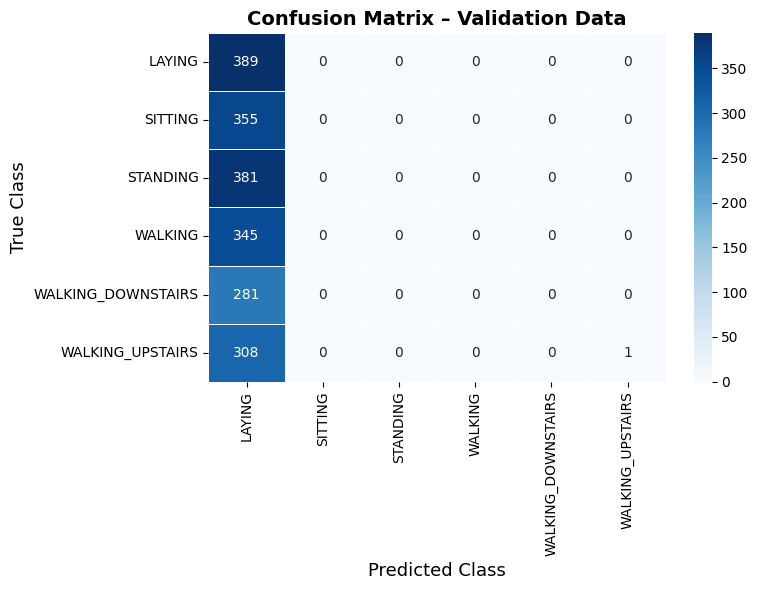

In [60]:
# Write the code for performance metrics evaluation
def evaluate_performance(y_true, y_pred, dataset_name):
    print(f"\nPerformance on {dataset_name} Data")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision (Micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (Micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (Micro):", f1_score(y_true, y_pred, average="micro"))

    print("Precision (Macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (Macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (Macro):", f1_score(y_true, y_pred, average="macro"))


def plot_confusion_matrix(y_true, y_pred, label, cmap='Blues'):
    """
    Plot a labelled confusion-matrix heatmap.
    """
    labels = sorted(np.unique(y_true))
    cm     = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=0.5)
    plt.xlabel('Predicted Class', fontsize=13)
    plt.ylabel('True Class',      fontsize=13)
    plt.title(f'Confusion Matrix – {label} Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print(y_val.shape, predictions_test.shape)
evaluate_performance(y_val, predictions_val, "Validation")
plot_confusion_matrix(y_val, predictions_val, "Validation")

In [14]:
# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_test = nb.predict(X_test)


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[343  39   0   0   0   7]
 [  4 328  20   0   0   4]
 [  0 282  94   1   0   4]
 [  0   0   0 257  37  50]
 [  0   0   0  16 219  46]
 [  0   0   0   5  20 284]]
Accuracy: 0.7402912621359223
Precision (Micro): 0.7402912621359223
Recall (Micro): 0.7402912621359223
F1-score (Micro): 0.7402912621359223
Precision (Macro): 0.7920065823677445
Recall (Macro): 0.7492269752807742
F1-score (Macro): 0.7304688835982263


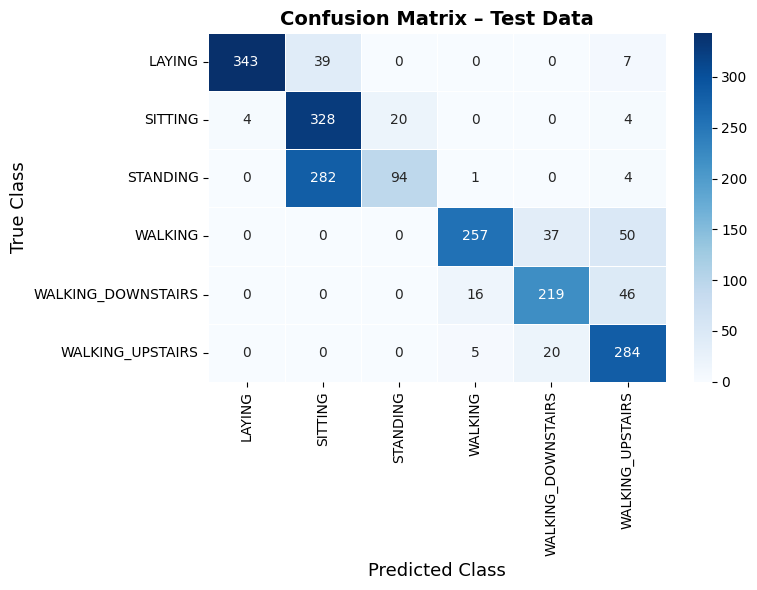

In [15]:
# Write the code for performance metrics evaluation
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [61]:
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_val = nb.predict(X_val)


(2060,) (2060,)

Performance on Validation Data
----------------------------------------
Confusion Matrix:
[[337  46   0   0   0   6]
 [  2 329  16   0   0   8]
 [  1 290  81   0   0   9]
 [  0   0   0 244  35  66]
 [  0   0   0  16 228  37]
 [  0   0   0   7  22 280]]
Accuracy: 0.7276699029126213
Precision (Micro): 0.7276699029126213
Recall (Micro): 0.7276699029126213
F1-score (Micro): 0.7276699029126213
Precision (Macro): 0.7874129515669445
Recall (Macro): 0.7384110067522546
F1-score (Macro): 0.7158034118832514


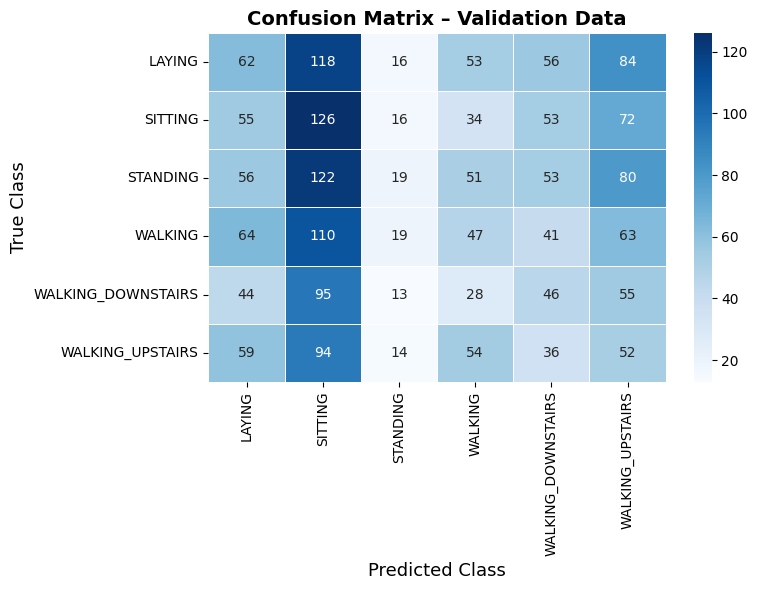

In [62]:
# Write the code for performance metrics evaluation
print(y_val.shape, predictions_val.shape)
evaluate_performance(y_val, predictions_val, "Validation")
plot_confusion_matrix(y_test, predictions_val, "Validation")

In [16]:
#for standarized activity dataset 

In [63]:
df_train = pd.read_csv("Data_for_Lab06/Activity_Scaled_Train.csv")
df_test = pd.read_csv("Data_for_Lab06/Activity_Scaled_Test.csv")
df_val = pd.read_csv("Data_for_Lab06/Activity_Scaled_Validation.csv")

In [64]:
X_train = df_train.drop('Activity', axis=1)
y_train = df_train['Activity']

In [65]:
X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

In [66]:
X_val = df_val.drop('Activity', axis=1)
y_val = df_val['Activity']

In [67]:
classes = np.unique(y_train)

class_means, class_covs, class_priors = {}, {}, {}

for cls in classes:
    X_cls = X_train[y_train == cls]
    class_means[cls] = np.mean(X_cls, axis=0)
    class_covs[cls] = np.cov(X_cls, rowvar=False)
    class_priors[cls] = X_cls.shape[0] / X_train.shape[0]

print("Finished Parameter Estimation\n")

numerators = []
for cls in classes:
    likelihood = multivariate_normal.pdf(
        np.array(X_test),
        mean=class_means[cls],
        cov=class_covs[cls],
        allow_singular=True
    )
    
    numerator = likelihood * class_priors[cls]
    numerators.append(numerator)

numerators = np.array(numerators)

total_probabilities = np.sum(numerators, axis=0).reshape(1, -1)

posteriors = numerators/total_probabilities

predictions_test = classes[np.argmax(posteriors, axis=0)]

print(f" Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")


numerators = np.swapaxes(numerators, 0, 1)
total_probabilities = np.sum(numerators, axis=1).reshape(-1, 1)
posteriors = numerators/total_probabilities
predictions_test = classes[np.argmax(posteriors, axis=1)]
print(f"\n Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")
print("\nFinished Test Prediction\n")

Finished Parameter Estimation



/home/user/.local/lib/python3.8/site-packages/scipy/stats/_multivariate.py:583: RuntimeWarning: overflow encountered in exp
  out = np.exp(self._logpdf(x, mean, cov_object))


 Numerator Shape: (6, 2060) 
 Total Probability Shape: (1, 2060) 
 Posterior Probability Shape: (6, 2060) 
 Prediction Shape: (2060,)

 Numerator Shape: (2060, 6) 
 Total Probability Shape: (2060, 1) 
 Posterior Probability Shape: (2060, 6) 
 Prediction Shape: (2060,)

Finished Test Prediction



/tmp/ipykernel_176776/536151776.py:29: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities
/tmp/ipykernel_176776/536151776.py:38: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities


/home/user/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[389   0   0   0   0   0]
 [355   0   1   0   0   0]
 [378   0   3   0   0   0]
 [198   0   0 121   6  19]
 [238   0   0   7  27   9]
 [224   0   0  14   4  67]]
Accuracy: 0.2946601941747573
Precision (Micro): 0.2946601941747573
Recall (Micro): 0.2946601941747573
F1-score (Micro): 0.2946601941747573
Precision (Macro): 0.5425666025513649
Recall (Macro): 0.2787553483352689
F1-score (Macro): 0.22889691569313667


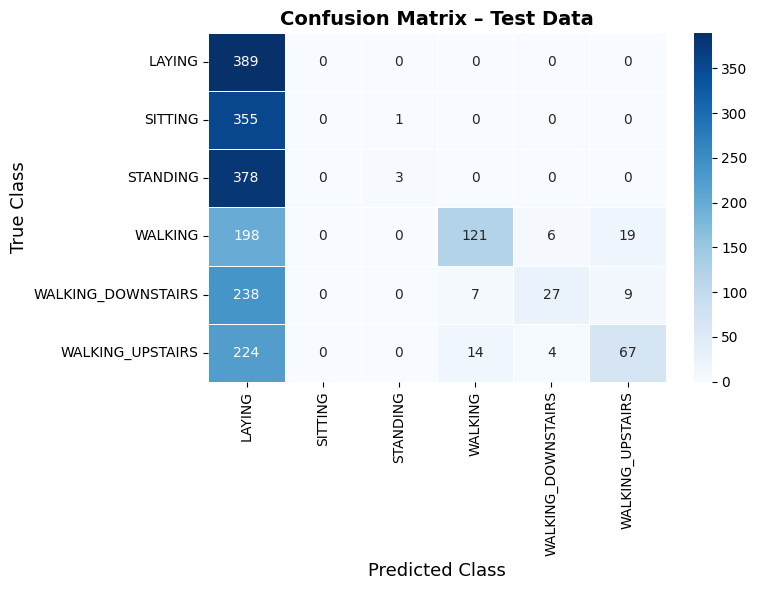

In [68]:
# Write the code for performance metrics evaluation
def evaluate_performance(y_true, y_pred, dataset_name):
    print(f"\nPerformance on {dataset_name} Data")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision (Micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (Micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (Micro):", f1_score(y_true, y_pred, average="micro"))

    print("Precision (Macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (Macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (Macro):", f1_score(y_true, y_pred, average="macro"))


def plot_confusion_matrix(y_true, y_pred, label, cmap='Blues'):
    """
    Plot a labelled confusion-matrix heatmap.
    """
    labels = sorted(np.unique(y_true))
    cm     = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=0.5)
    plt.xlabel('Predicted Class', fontsize=13)
    plt.ylabel('True Class',      fontsize=13)
    plt.title(f'Confusion Matrix – {label} Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [69]:
# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_test = nb.predict(X_test)


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[343  39   0   0   0   7]
 [  4 328  20   0   0   4]
 [  0 282  94   1   0   4]
 [  0   0   0 257  37  50]
 [  0   0   0  16 219  46]
 [  0   0   0   5  20 284]]
Accuracy: 0.7402912621359223
Precision (Micro): 0.7402912621359223
Recall (Micro): 0.7402912621359223
F1-score (Micro): 0.7402912621359223
Precision (Macro): 0.7920065823677445
Recall (Macro): 0.7492269752807742
F1-score (Macro): 0.7304688835982263


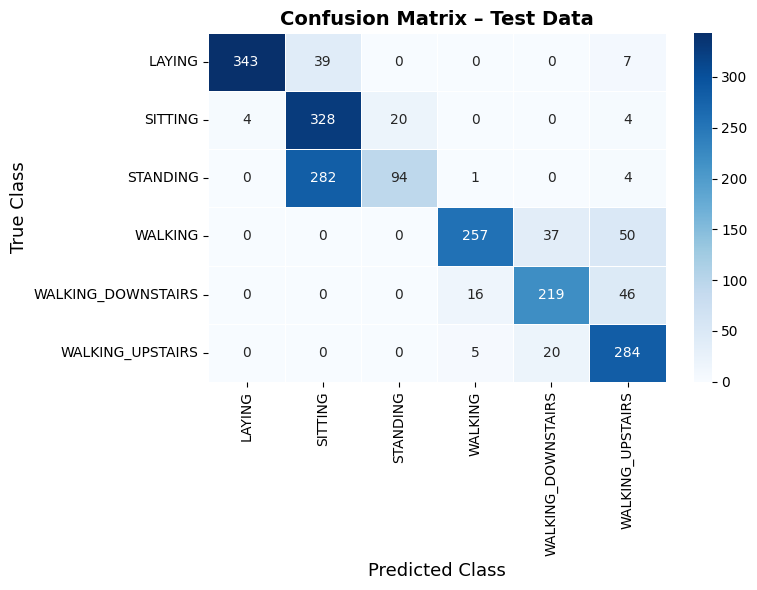

In [70]:
# Write the code for performance metrics evaluation
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [71]:
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_val = nb.predict(X_val)


(2060,) (2060,)

Performance on Validation Data
----------------------------------------
Confusion Matrix:
[[337  46   0   0   0   6]
 [  2 329  16   0   0   8]
 [  1 290  81   0   0   9]
 [  0   0   0 244  35  66]
 [  0   0   0  16 228  37]
 [  0   0   0   7  22 280]]
Accuracy: 0.7276699029126213
Precision (Micro): 0.7276699029126213
Recall (Micro): 0.7276699029126213
F1-score (Micro): 0.7276699029126213
Precision (Macro): 0.7874129515669445
Recall (Macro): 0.7384110067522546
F1-score (Macro): 0.7158034118832514


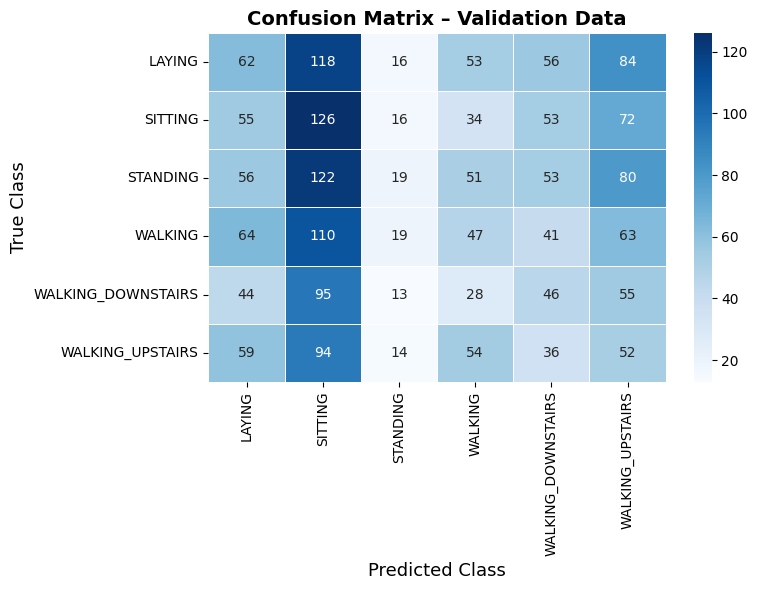

In [72]:
# Write the code for performance metrics evaluation
print(y_val.shape, predictions_val.shape)
evaluate_performance(y_val, predictions_val, "Validation")
plot_confusion_matrix(y_test, predictions_val, "Validation")

In [73]:
#for pcaall dataset 

In [74]:
df_train = pd.read_csv("Data_for_Lab06/Activity_PCAAll_Train.csv")
df_test = pd.read_csv("Data_for_Lab06/Activity_PCAAll_Test.csv")
df_val = pd.read_csv("Data_for_Lab06/Activity_PCAAll_Validation.csv")

In [75]:
X_train = df_train.drop('Activity', axis=1)
y_train = df_train['Activity']

In [76]:
X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

In [77]:
X_val = df_val.drop('Activity', axis=1)
y_val = df_val['Activity']

In [78]:
classes = np.unique(y_train)

class_means, class_covs, class_priors = {}, {}, {}

for cls in classes:
    X_cls = X_train[y_train == cls]
    class_means[cls] = np.mean(X_cls, axis=0)
    class_covs[cls] = np.cov(X_cls, rowvar=False)
    class_priors[cls] = X_cls.shape[0] / X_train.shape[0]

print("Finished Parameter Estimation\n")

numerators = []
for cls in classes:
    likelihood = multivariate_normal.pdf(
        np.array(X_test),
        mean=class_means[cls],
        cov=class_covs[cls],
        allow_singular=True
    )
    
    numerator = likelihood * class_priors[cls]
    numerators.append(numerator)

numerators = np.array(numerators)

total_probabilities = np.sum(numerators, axis=0).reshape(1, -1)

posteriors = numerators/total_probabilities

predictions_test = classes[np.argmax(posteriors, axis=0)]

print(f" Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")


numerators = np.swapaxes(numerators, 0, 1)
total_probabilities = np.sum(numerators, axis=1).reshape(-1, 1)
posteriors = numerators/total_probabilities
predictions_test = classes[np.argmax(posteriors, axis=1)]
print(f"\n Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")
print("\nFinished Test Prediction\n")

Finished Parameter Estimation



/home/user/.local/lib/python3.8/site-packages/scipy/stats/_multivariate.py:583: RuntimeWarning: overflow encountered in exp
  out = np.exp(self._logpdf(x, mean, cov_object))


 Numerator Shape: (6, 2060) 
 Total Probability Shape: (1, 2060) 
 Posterior Probability Shape: (6, 2060) 
 Prediction Shape: (2060,)

 Numerator Shape: (2060, 6) 
 Total Probability Shape: (2060, 1) 
 Posterior Probability Shape: (2060, 6) 
 Prediction Shape: (2060,)

Finished Test Prediction



/tmp/ipykernel_176776/536151776.py:29: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities
/tmp/ipykernel_176776/536151776.py:38: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities


/home/user/.local/lib/python3.8/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[389   0   0   0   0   0]
 [356   0   0   0   0   0]
 [381   0   0   0   0   0]
 [344   0   0   0   0   0]
 [281   0   0   0   0   0]
 [308   0   0   0   0   1]]
Accuracy: 0.18932038834951456
Precision (Micro): 0.18932038834951456
Recall (Micro): 0.18932038834951456
F1-score (Micro): 0.18932038834951456
Precision (Macro): 0.19815444390480816
Recall (Macro): 0.16720604099244876
F1-score (Macro): 0.05404367840326094


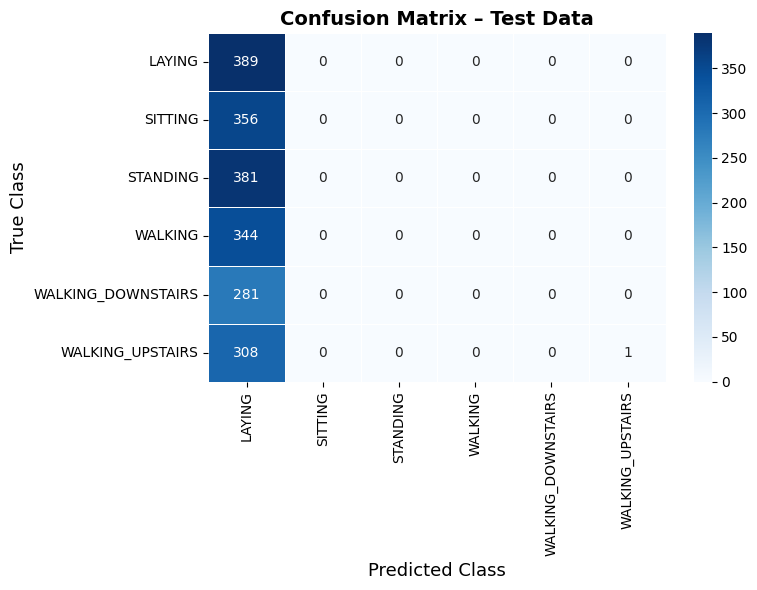

In [79]:
# Write the code for performance metrics evaluation
def evaluate_performance(y_true, y_pred, dataset_name):
    print(f"\nPerformance on {dataset_name} Data")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision (Micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (Micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (Micro):", f1_score(y_true, y_pred, average="micro"))

    print("Precision (Macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (Macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (Macro):", f1_score(y_true, y_pred, average="macro"))


def plot_confusion_matrix(y_true, y_pred, label, cmap='Blues'):
    """
    Plot a labelled confusion-matrix heatmap.
    """
    labels = sorted(np.unique(y_true))
    cm     = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=0.5)
    plt.xlabel('Predicted Class', fontsize=13)
    plt.ylabel('True Class',      fontsize=13)
    plt.title(f'Confusion Matrix – {label} Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [80]:
# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_test = nb.predict(X_test)


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[158 120  81   0  21   9]
 [ 31 121 174   1  18  11]
 [ 35   4 321   1  10  10]
 [  2   1   1 234  84  22]
 [  0   0   0  25 206  50]
 [  1   0   0   6  60 242]]
Accuracy: 0.6223300970873786
Precision (Micro): 0.6223300970873786
Recall (Micro): 0.6223300970873786
F1-score (Micro): 0.6223300970873786
Precision (Macro): 0.6400690962509324
Recall (Macro): 0.6308461926471605
F1-score (Macro): 0.6163601321647731


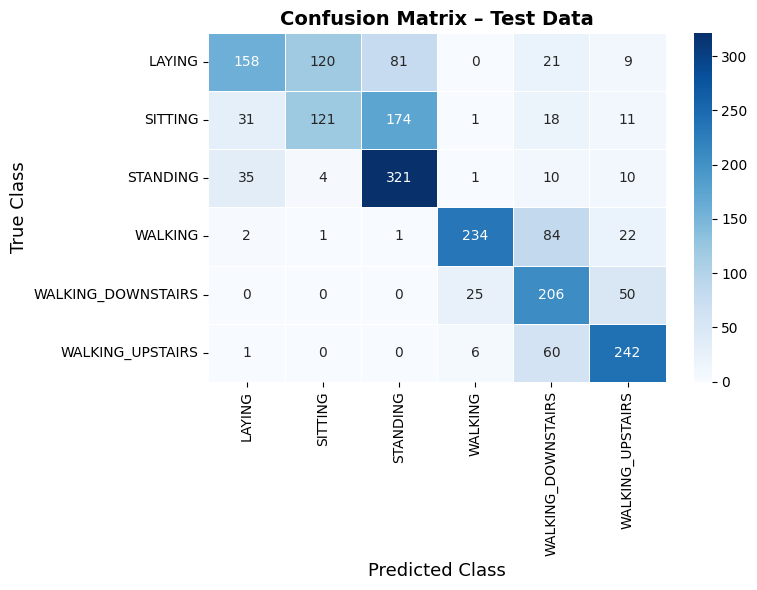

In [81]:
# Write the code for performance metrics evaluation
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [82]:
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_val = nb.predict(X_val)


(2060,) (2060,)

Performance on Validation Data
----------------------------------------
Confusion Matrix:
[[140 136  72   0  30  11]
 [ 28 140 162   2  16   7]
 [ 36   4 317   2  12  10]
 [  2   1   4 221  86  31]
 [  1   0   0  22 212  46]
 [  1   0   0   3  63 242]]
Accuracy: 0.6174757281553398
Precision (Micro): 0.6174757281553398
Recall (Micro): 0.6174757281553398
F1-score (Micro): 0.6174757281553398
Precision (Macro): 0.6383069436645497
Recall (Macro): 0.6274139994253282
F1-score (Macro): 0.6121650052651354


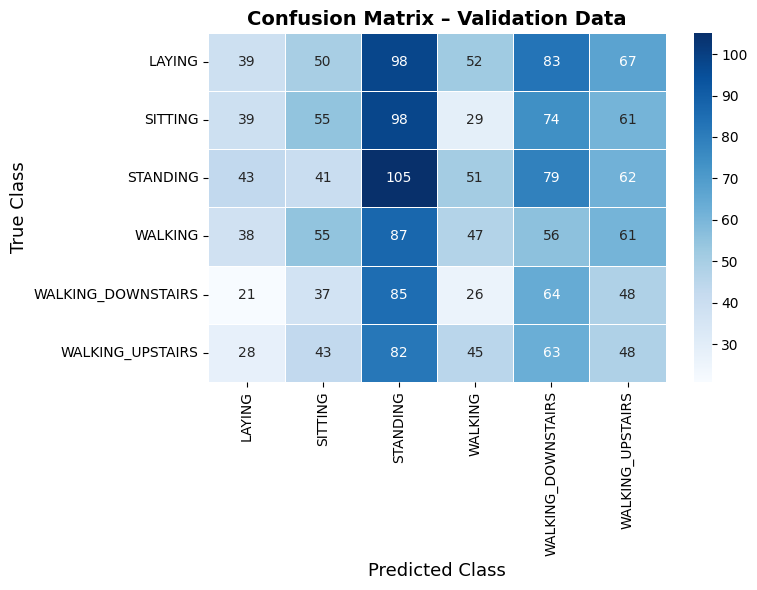

In [83]:
# Write the code for performance metrics evaluation
print(y_val.shape, predictions_val.shape)
evaluate_performance(y_val, predictions_val, "Validation")
plot_confusion_matrix(y_test, predictions_val, "Validation")

In [84]:
# for pca 99 dataset

In [85]:
df_train = pd.read_csv("Data_for_Lab06/Activity_PCA99_Train.csv")
df_test = pd.read_csv("Data_for_Lab06/Activity_PCA99_Test.csv")
df_val = pd.read_csv("Data_for_Lab06/Activity_PCA99_Validation.csv")

In [86]:
X_train = df_train.drop('Activity', axis=1)
y_train = df_train['Activity']

In [87]:
X_test = df_test.drop('Activity', axis=1)
y_test = df_test['Activity']

In [88]:
X_val = df_val.drop('Activity', axis=1)
y_val = df_val['Activity']

In [89]:
classes = np.unique(y_train)

class_means, class_covs, class_priors = {}, {}, {}

for cls in classes:
    X_cls = X_train[y_train == cls]
    class_means[cls] = np.mean(X_cls, axis=0)
    class_covs[cls] = np.cov(X_cls, rowvar=False)
    class_priors[cls] = X_cls.shape[0] / X_train.shape[0]

print("Finished Parameter Estimation\n")

numerators = []
for cls in classes:
    likelihood = multivariate_normal.pdf(
        np.array(X_test),
        mean=class_means[cls],
        cov=class_covs[cls],
        allow_singular=True
    )
    
    numerator = likelihood * class_priors[cls]
    numerators.append(numerator)

numerators = np.array(numerators)

total_probabilities = np.sum(numerators, axis=0).reshape(1, -1)

posteriors = numerators/total_probabilities

predictions_test = classes[np.argmax(posteriors, axis=0)]

print(f" Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")


numerators = np.swapaxes(numerators, 0, 1)
total_probabilities = np.sum(numerators, axis=1).reshape(-1, 1)
posteriors = numerators/total_probabilities
predictions_test = classes[np.argmax(posteriors, axis=1)]
print(f"\n Numerator Shape: {numerators.shape} \n Total Probability Shape: {total_probabilities.shape} \n Posterior Probability Shape: {posteriors.shape} \n Prediction Shape: {predictions_test.shape}")
print("\nFinished Test Prediction\n")

Finished Parameter Estimation

 Numerator Shape: (6, 2060) 
 Total Probability Shape: (1, 2060) 
 Posterior Probability Shape: (6, 2060) 
 Prediction Shape: (2060,)

 Numerator Shape: (2060, 6) 
 Total Probability Shape: (2060, 1) 
 Posterior Probability Shape: (2060, 6) 
 Prediction Shape: (2060,)

Finished Test Prediction



/tmp/ipykernel_176776/536151776.py:29: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities
/tmp/ipykernel_176776/536151776.py:38: RuntimeWarning: invalid value encountered in divide
  posteriors = numerators/total_probabilities


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[389   0   0   0   0   0]
 [  2 330  24   0   0   0]
 [  0  12 369   0   0   0]
 [  0   0   0 341   2   1]
 [  0   0   0   0 279   2]
 [  0   0   0   1   2 306]]
Accuracy: 0.9776699029126213
Precision (Micro): 0.9776699029126213
Recall (Micro): 0.9776699029126213
F1-score (Micro): 0.9776699029126213
Precision (Macro): 0.978660249801162
Recall (Macro): 0.9783205205539417
F1-score (Macro): 0.9783841782095714


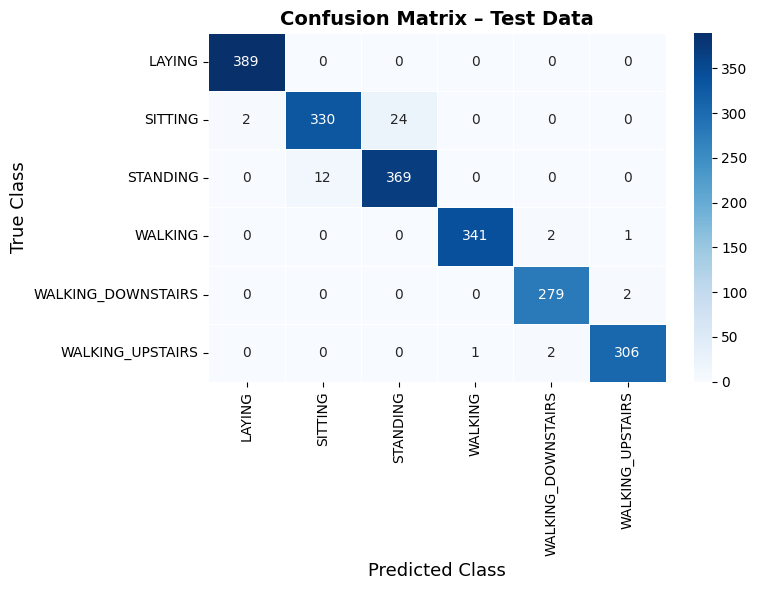

In [90]:
# Write the code for performance metrics evaluation
def evaluate_performance(y_true, y_pred, dataset_name):
    print(f"\nPerformance on {dataset_name} Data")
    print("-" * 40)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    print("Accuracy:", accuracy_score(y_true, y_pred))

    print("Precision (Micro):", precision_score(y_true, y_pred, average="micro"))
    print("Recall (Micro):", recall_score(y_true, y_pred, average="micro"))
    print("F1-score (Micro):", f1_score(y_true, y_pred, average="micro"))

    print("Precision (Macro):", precision_score(y_true, y_pred, average="macro"))
    print("Recall (Macro):", recall_score(y_true, y_pred, average="macro"))
    print("F1-score (Macro):", f1_score(y_true, y_pred, average="macro"))


def plot_confusion_matrix(y_true, y_pred, label, cmap='Blues'):
    """
    Plot a labelled confusion-matrix heatmap.
    """
    labels = sorted(np.unique(y_true))
    cm     = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                cbar=True, linewidths=0.5)
    plt.xlabel('Predicted Class', fontsize=13)
    plt.ylabel('True Class',      fontsize=13)
    plt.title(f'Confusion Matrix – {label} Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [91]:
# Train Naive Bayes model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_test = nb.predict(X_test)


(2060,) (2060,)

Performance on Test Data
----------------------------------------
Confusion Matrix:
[[360  21   0   0   8   0]
 [ 23 277  40   0  16   0]
 [ 18  20 334   1   7   1]
 [  0   0   0 290  43  11]
 [  0   0   0  26 212  43]
 [  0   0   0   2  29 278]]
Accuracy: 0.85
Precision (Micro): 0.85
Recall (Micro): 0.85
F1-score (Micro): 0.85
Precision (Macro): 0.8464690897743948
Recall (Macro): 0.8462213681413747
F1-score (Macro): 0.8450639244473653


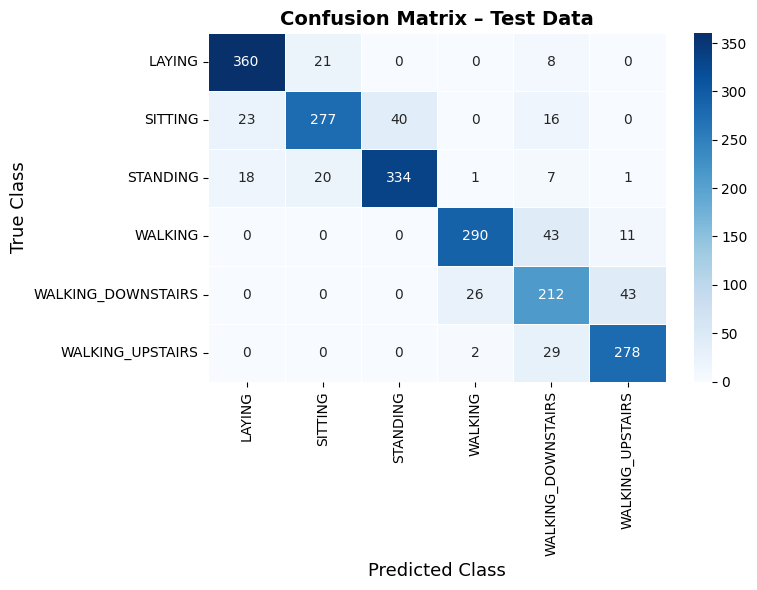

In [92]:
# Write the code for performance metrics evaluation
print(y_test.shape, predictions_test.shape)
evaluate_performance(y_test, predictions_test, "Test")
plot_confusion_matrix(y_test, predictions_test, "Test")

In [93]:
nb = GaussianNB()
nb.fit(X_train, y_train)

# Predicted Label
predictions_val = nb.predict(X_val)


(2060,) (2060,)

Performance on Validation Data
----------------------------------------
Confusion Matrix:
[[363  15   0   0  11   0]
 [ 20 276  41   1  17   0]
 [ 20  19 333   1   8   0]
 [  0   0   0 285  43  17]
 [  0   0   0  25 213  43]
 [  0   0   0   5  28 276]]
Accuracy: 0.8475728155339806
Precision (Micro): 0.8475728155339806
Recall (Micro): 0.8475728155339806
F1-score (Micro): 0.8475728155339806
Precision (Macro): 0.8445914213763728
Recall (Macro): 0.843656741324334
F1-score (Macro): 0.8424201398937706


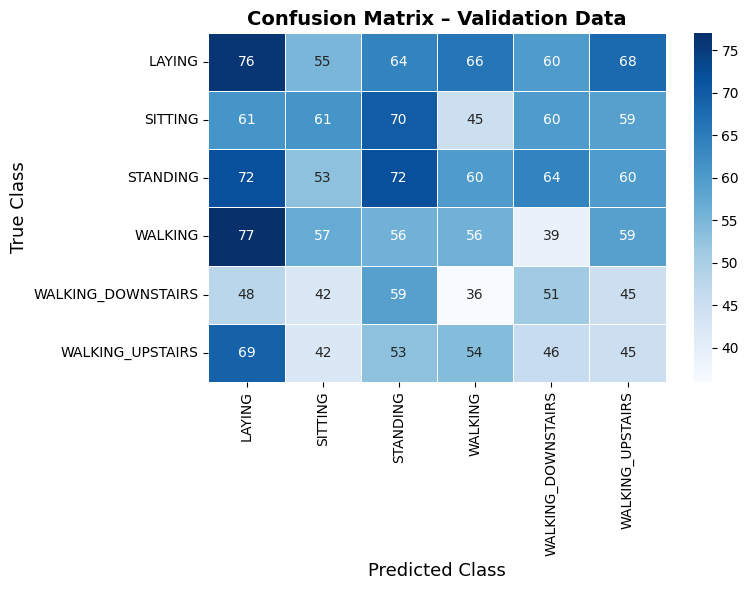

In [94]:
# Write the code for performance metrics evaluation
print(y_val.shape, predictions_val.shape)
evaluate_performance(y_val, predictions_val, "Validation")
plot_confusion_matrix(y_test, predictions_val, "Validation")